In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
raw_returns = pd.read_csv('../data/quarterly_returns.csv', index_col=0, parse_dates=True)
raw_returns.head()

,AGG,SPY,PE,NPI
Date,,,,
2000-03-31,NaN,2.643259,7.0,3.20
2000-06-30,NaN,-3.159936,3.5,3.10
2000-09-30,NaN,-0.891586,-1.8,3.00
2000-12-31,NaN,-8.379575,-3.5,2.85
2001-03-31,NaN,-10.811495,-2.5,2.20


# plot raw returns

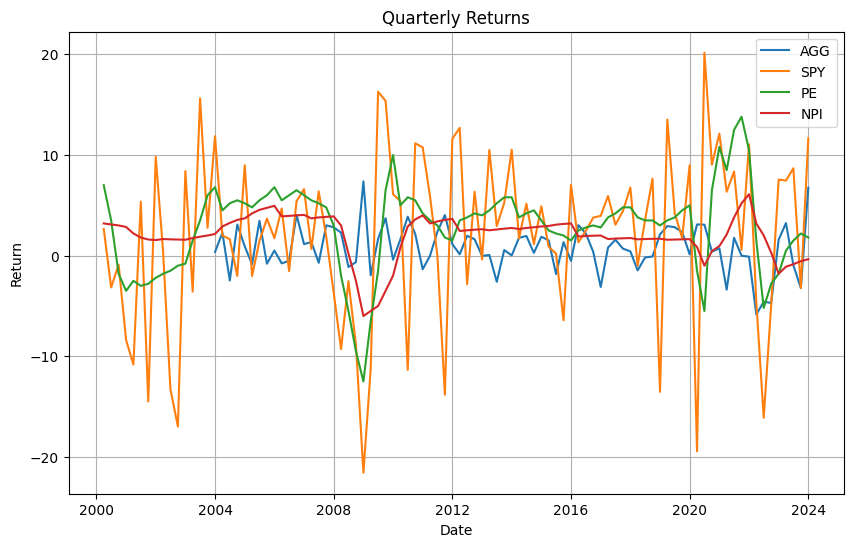

In [3]:
plt.figure(figsize=(10, 6))
for col in raw_returns.columns:
    plt.plot(raw_returns.index, raw_returns[col], label=col)
plt.title(f'Quarterly Returns')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend()
plt.grid()
plt.show()

# plot NAV

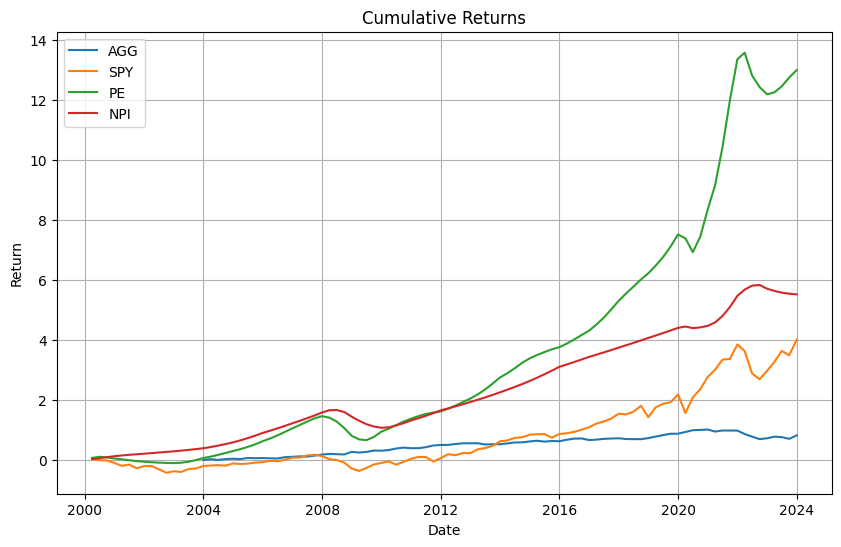

In [4]:
plt.figure(figsize=(10, 6))
for col in raw_returns.columns:
    plt.plot(raw_returns.index, (1 + raw_returns[col]/100).cumprod() - 1, label=col)
plt.title('Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend()
plt.grid()
plt.show()

# Unsmooth

Estimated alpha (lag-1 autocorrelation) by asset:


,alpha_lag1
AGG,0.0473
SPY,0.0296
PE,0.7939
NPI,0.9012


Annualised volatility comparison by asset:


,ann_vol_raw,ann_vol_unsmoothed,vol_ratio_unsmoothed_to_raw
AGG,0.0461,0.0486,1.0549
SPY,0.1667,0.1717,1.0301
PE,0.0857,0.2519,2.9380
NPI,0.0426,0.1866,4.3795


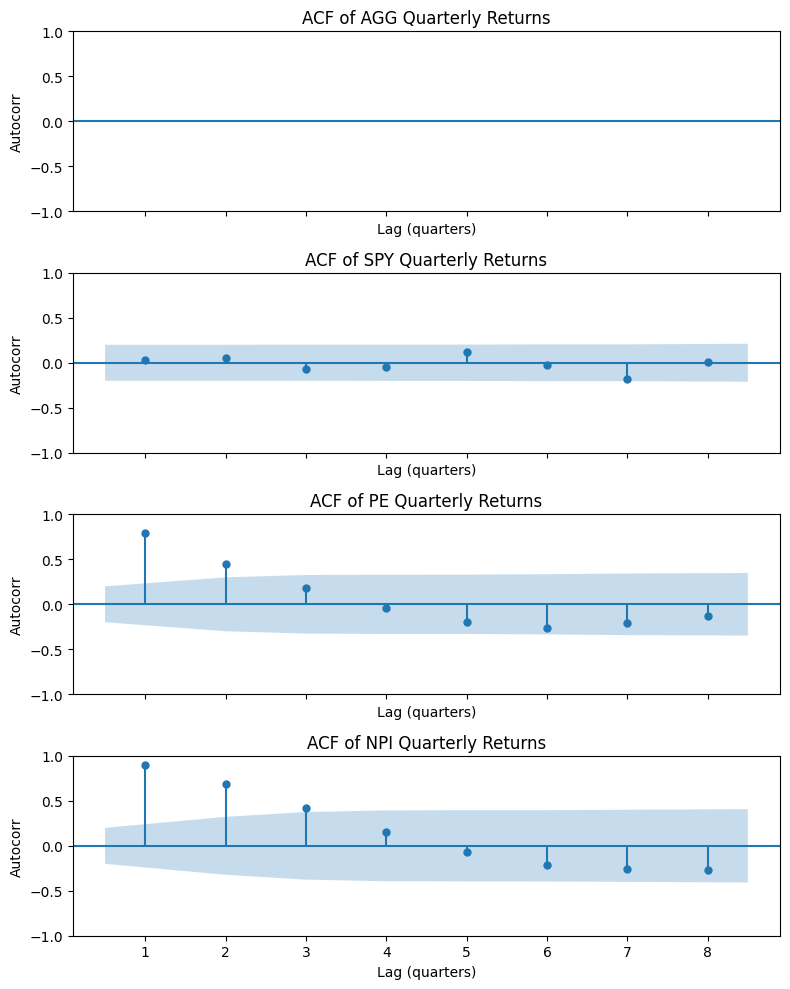

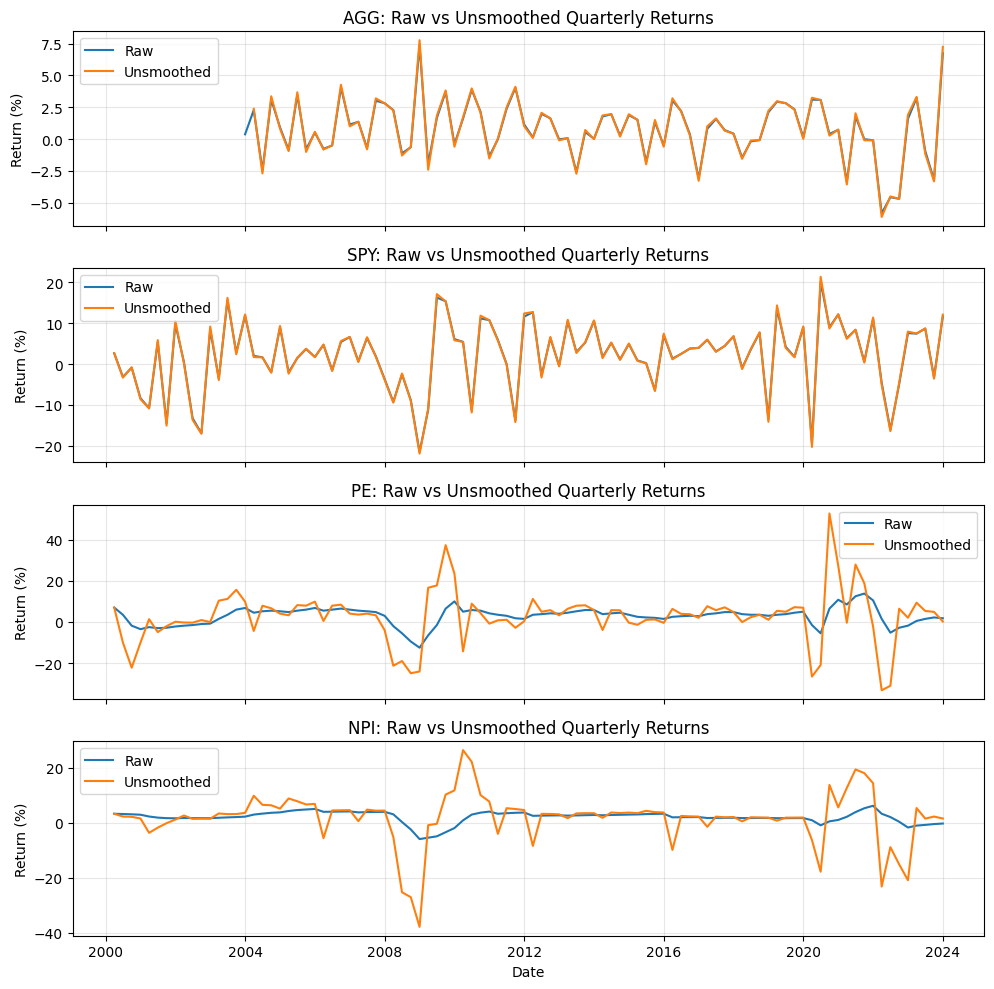

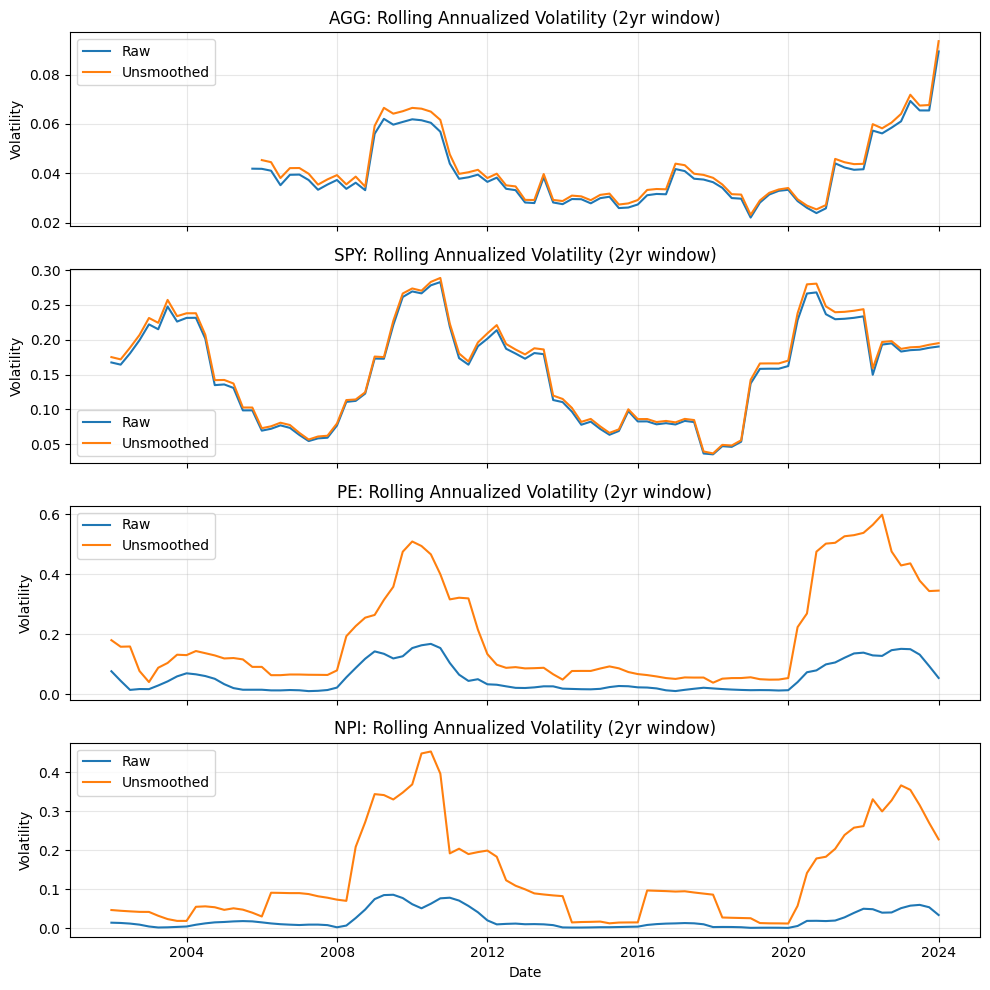

In [5]:
import numpy as np
import pandas as pd
from typing import Optional

def fgw_unsmooth(series: pd.Series, alpha: Optional[float] = None, max_abs_alpha: float = 0.99):
    """
    Fisher-Geltner-Webb unsmoothing for one return series.
    series is expected in percent units (e.g., 2.5 means 2.5%).
    """
    r = series.astype(float).copy()

    if alpha is None:
        alpha = r.autocorr(lag=1)

    if pd.isna(alpha):
        alpha = 0.0

    alpha = float(np.clip(alpha, -max_abs_alpha, max_abs_alpha))

    r_unsmoothed = (r - alpha * r.shift(1)) / (1 - alpha)
    r_unsmoothed.iloc[0] = r.iloc[0]

    return r_unsmoothed, alpha

# Apply FGW unsmoothing to each asset column in raw_returns
unsmoothed_returns = pd.DataFrame(index=raw_returns.index)
alpha_by_asset = {}

for asset in raw_returns.columns:
    unsmoothed_series, alpha = fgw_unsmooth(raw_returns[asset])
    unsmoothed_returns[asset] = unsmoothed_series
    alpha_by_asset[asset] = alpha

alpha_table = pd.Series(alpha_by_asset, name="alpha_lag1").to_frame()
vol_compare = pd.DataFrame({
    "ann_vol_raw": raw_returns.std(ddof=1) * np.sqrt(4) / 100,
    "ann_vol_unsmoothed": unsmoothed_returns.std(ddof=1) * np.sqrt(4) / 100
})
vol_compare["vol_ratio_unsmoothed_to_raw"] = vol_compare["ann_vol_unsmoothed"] / vol_compare["ann_vol_raw"]

print("Estimated alpha (lag-1 autocorrelation) by asset:")
display(alpha_table.round(4))

print("Annualised volatility comparison by asset:")
display(vol_compare.round(4))

unsmoothed_returns.head()

# 2. Plot ACF for each asset
from statsmodels.graphics.tsaplots import plot_acf
fig, axes = plt.subplots(len(raw_returns.columns), 1, figsize=(8, 2.5*len(raw_returns.columns)), sharex=True)
if len(raw_returns.columns) == 1:
    axes = [axes]
for i, asset in enumerate(raw_returns.columns):
    plot_acf(raw_returns[asset].astype(float), lags=8, zero=False, alpha=0.05, ax=axes[i])
    axes[i].set_title(f"ACF of {asset} Quarterly Returns")
    axes[i].set_xlabel("Lag (quarters)")
    axes[i].set_ylabel("Autocorr")
plt.tight_layout()
plt.show()

# 3. Plot unsmoothed vs raw returns for each asset
fig, axes = plt.subplots(len(raw_returns.columns), 1, figsize=(10, 2.5*len(raw_returns.columns)), sharex=True)
if len(raw_returns.columns) == 1:
    axes = [axes]
for i, asset in enumerate(raw_returns.columns):
    axes[i].plot(raw_returns.index, raw_returns[asset], label="Raw", lw=1.5)
    axes[i].plot(unsmoothed_returns.index, unsmoothed_returns[asset], label="Unsmoothed", lw=1.5)
    axes[i].set_title(f"{asset}: Raw vs Unsmoothed Quarterly Returns")
    axes[i].set_ylabel("Return (%)")
    axes[i].legend()
    axes[i].grid(alpha=0.3)
plt.xlabel("Date")
plt.tight_layout()
plt.show()

# 4. Plot rolling annualized volatility (2-year window) for each asset
window = 8  # 8 quarters = 2 years
rolling_vol = pd.DataFrame(index=raw_returns.index)
for asset in raw_returns.columns:
    rolling_vol[f"{asset}_raw"] = raw_returns[asset].rolling(window=window).std(ddof=1) * np.sqrt(4) / 100
    rolling_vol[f"{asset}_unsmoothed"] = unsmoothed_returns[asset].rolling(window=window).std(ddof=1) * np.sqrt(4) / 100
fig, axes = plt.subplots(len(raw_returns.columns), 1, figsize=(10, 2.5*len(raw_returns.columns)), sharex=True)
if len(raw_returns.columns) == 1:
    axes = [axes]
for i, asset in enumerate(raw_returns.columns):
    axes[i].plot(rolling_vol.index, rolling_vol[f"{asset}_raw"], label="Raw", lw=1.5)
    axes[i].plot(rolling_vol.index, rolling_vol[f"{asset}_unsmoothed"], label="Unsmoothed", lw=1.5)
    axes[i].set_title(f"{asset}: Rolling Annualized Volatility (2yr window)")
    axes[i].set_ylabel("Volatility")
    axes[i].legend()
    axes[i].grid(alpha=0.3)
plt.xlabel("Date")
plt.tight_layout()
plt.show()

### Insights from ACF, Unsmoothed Returns, and Volatility

- **ACF plots**: AGG and SPY show very low autocorrelation, confirming they are not smoothed(no need to unsmooth); PE and NPI show high autocorrelation, indicating appraisal smoothing.
- **Return curves**: Unsmoothed returns for PE/NPI are much more volatile and spiky, while AGG/SPY change little after unsmoothing.
- **Volatility curves**: Unsmoothed volatility for PE/NPI is much higher and more responsive to market stress, while AGG/SPY volatility is only slightly higher after unsmoothing.
- **Conclusion**: Appraisal smoothing in private assets (PE/NPI) significantly understates true risk. Public assets (AGG/SPY) are already marked-to-market, so unsmoothing has little effect.

In [8]:
df = pd.concat([raw_returns[['SPY', 'AGG']], unsmoothed_returns[['PE', 'NPI']]], axis=1)
df.to_csv('../data/processed_returns.csv')
df.head()

,SPY,AGG,PE,NPI
Date,,,,
2000-03-31,2.643259,NaN,7.000000,3.200000
2000-06-30,-3.159936,NaN,-9.985944,2.188084
2000-09-30,-0.891586,NaN,-22.221572,2.088084
2000-12-31,-8.379575,NaN,-10.050315,1.482126
2001-03-31,-10.811495,NaN,1.353127,-3.727454
